In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [32]:
data = pd.read_csv("planetaryData.csv")
print (data.shape)
missing = data.isnull().sum()
missing_per = (data.isnull().sum()/len(data))*100
missing_summary = pd.DataFrame({
    "missing sum" : missing,
    "missing percent" : missing_per.round(1)
})
print (missing_summary.sort_values("missing percent" , ascending = False))

(4575, 23)
                               missing sum  missing percent
Insolation Flux                       4205             91.9
Equilibrium Temperature               3650             79.8
Spectral Type                         3647             79.7
Eccentricity                          2868             62.7
Mass                                  2569             56.2
Orbit Semi-Major Axis                 1812             39.6
Stellar Metallicity Ratio             1383             30.2
Stellar Metallicity                   1371             30.0
Stellar Mass                           731             16.0
Stellar Surface Gravity                603             13.2
Stellar Radius                         447              9.8
Stellar Effective Temperature          349              7.6
Gaia Magnitude                         175              3.8
Orbital Period Days                    162              3.5
Distance                               104              2.3
Discovery Year               

In [33]:
dropped_cols = [
    "Insolation Flux", "Equilibrium Temperature", "Spectral Type", "Discovery Facility"
]
clean_d = data.drop(columns = dropped_cols)
print (clean_d.shape)
print (clean_d.head())

(4575, 19)
   No. Planet Name Planet Host  Num Stars  Num Planets Discovery Method  \
0    1    11 Com b      11 Com          2            1  Radial Velocity   
1    2    11 UMi b      11 UMi          1            1  Radial Velocity   
2    3    14 And b      14 And          1            1  Radial Velocity   
3    4    14 Her b      14 Her          1            2  Radial Velocity   
4    5  16 Cyg B b    16 Cyg B          3            1  Radial Velocity   

   Discovery Year  Orbital Period Days  Orbit Semi-Major Axis       Mass  \
0            2007            326.03000                   1.29  6165.6000   
1            2009            516.21997                   1.53  4684.8142   
2            2008            185.84000                   0.83  1525.5000   
3            2002           1773.40002                   2.93  1481.0878   
4            1996            798.50000                   1.66   565.7374   

   Eccentricity  Stellar Effective Temperature  Stellar Radius  Stellar Mass  \
0

 Does heavier stars produce heavier planets?  The correlation between stellar mass and planet mass is 0.3, which is a moderate correlation. This implies that stellar mass is not the sole determinant of planet mass. However, this correlation means massive stars tend to host massive planets. This is consistent with nebular formation theory (planets form from the same materials forming the parent star) P-value of 0 means the probability of the result happening by random is 0 (basically there is no coincidence), the result is real.

working with 440 planets after filtering
points used for trend line: 440


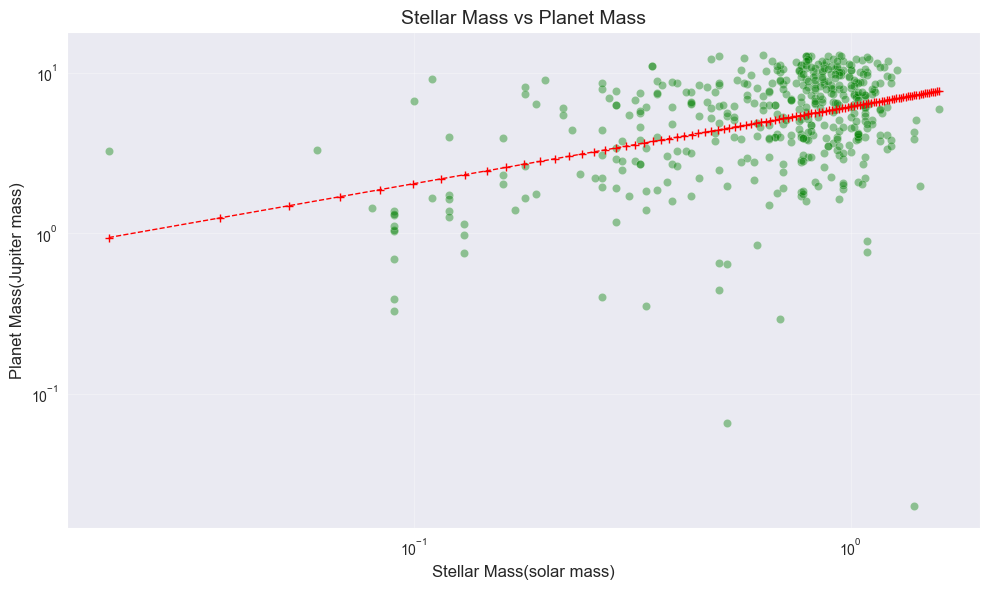

correlation(r): 0.391
P-value: 0.000000
Slope: 0.481


In [34]:
plot_data = clean_d.dropna(subset=["Stellar Mass", "Mass"])
plot_data = plot_data[plot_data["Mass"]<13]
plot_data = plot_data[plot_data["Mass"] > 0]
plot_data = plot_data[plot_data["Mass"] > 0]
print (f"working with {len(plot_data)} planets after filtering")

fig, ax = plt.subplots(figsize = (10,6))
ax.scatter(
    plot_data["Stellar Mass"],
    plot_data["Mass"],
    alpha = 0.4,
    color = "green",
    edgecolors = "white",
    linewidths = 0.3,
    s = 35
)
log_x = np.log10(plot_data["Stellar Mass"])
log_y = np.log10(plot_data["Mass"])
mask =np.isfinite(log_x) & np.isfinite(log_y)
log_x_clean = log_x[mask]
log_y_clean = log_y[mask]
print (f"points used for trend line: {mask.sum()}")

slope, intercept, r_value, p_value, std_err = stats.linregress(log_x, log_y)
x_line = np.linspace(
    plot_data["Stellar Mass"].min(),
    plot_data["Stellar Mass"].max(),
    100
)

ax.plot(
    x_line,
    10**(slope*np.log10(x_line) + intercept),
    linestyle = "--",
    linewidth = 1,
    marker = "+",
    color = "red",
    label = f"Trend(r={r_value:.2f})"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Stellar Mass(solar mass)", fontsize = 12)
ax.set_ylabel("Planet Mass(Jupiter mass)", fontsize = 12)
ax.set_title("Stellar Mass vs Planet Mass", fontsize = 14)
ax.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()
print (f"correlation(r): {r_value:.3f}")
print (f"P-value: {p_value:.6f}")
print (f"Slope: {slope:.3f}")


Does Stellar metallicity influence the number of planets a particular star hosts? In theory, stars with high metallicity host more planets, as there are more materials to form from,more rocky materials to compact. The result of analysis on this dataset, however, disagrees with this assumption.Why? the r value shows (-0.11) almost no correlation, meaning that the relationship is basically flat. This is because most stars in the dataset have a metallicity close to 0 anyway, detection bias whereby we find planets around certain types of stars more easily, and the number of planets discovered around a particular star are limited to what the telescope can see only, not the reality. The conclusion is that the dataset reflects what kepler could see not the true astrophysical relationship.

Working with 3204 stars
   Metallicity Bin  Num Planets Bin Center
0    (-1.0, -0.85]     1.250000    -0.9250
1   (-0.85, -0.69]     1.200000    -0.7700
2   (-0.69, -0.54]     2.958333    -0.6150
3   (-0.54, -0.38]     1.982143    -0.4600
4   (-0.38, -0.23]     2.176471    -0.3050
5  (-0.23, -0.073]     1.735849    -0.1515
6  (-0.073, 0.081]     1.414439     0.0040
7    (0.081, 0.24]     1.559068     0.1605
8     (0.24, 0.39]     1.563934     0.3150
9     (0.39, 0.55]     1.406250     0.4700


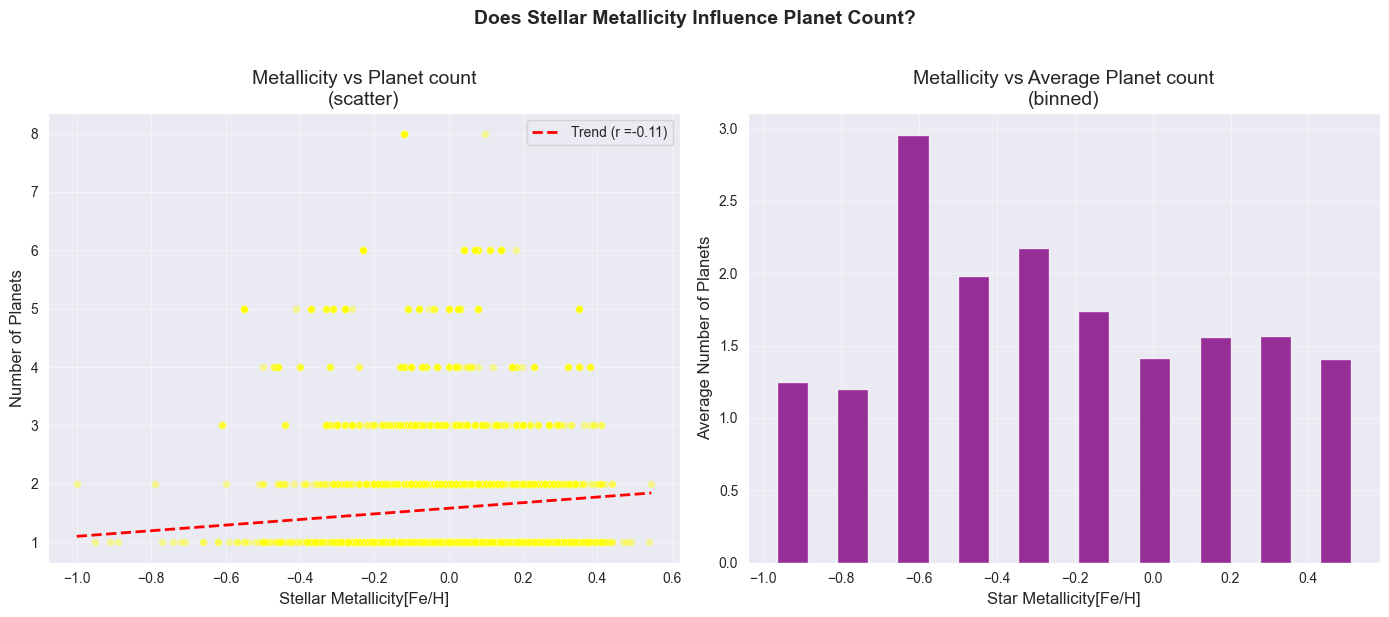

correlation(r): -0.108
P-value: 0.000000
Slope: -0.659


In [35]:
plot_dataZ = clean_d.dropna(subset=["Stellar Metallicity", "Num Planets"])
plot_dataZ = plot_dataZ[plot_dataZ["Stellar Metallicity"] > -1.5]
print (f"Working with {len(plot_dataZ)} stars")
plot_dataZ = plot_dataZ.copy()
plot_dataZ["Metallicity Bin"] = pd.cut(
    plot_dataZ["Stellar Metallicity"],
    bins = 10,
    precision = 2
)
bin_avg = plot_dataZ.groupby("Metallicity Bin", observed = True)["Num Planets"].mean().reset_index()
bin_avg["Bin Center"] = bin_avg["Metallicity Bin"].apply(lambda x: x.mid)
print (bin_avg)
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (14,6))
axes[0].scatter(
    plot_dataZ["Stellar Metallicity"],
    plot_dataZ["Num Planets"],
    alpha = 0.4,
    color = "yellow",
    edgecolors = "white",
    linewidths = 0.3,
    s = 30
)
slope2, intercept2, r2, p2, se2 = stats.linregress(
    plot_dataZ["Stellar Metallicity"],
    plot_dataZ["Num Planets"]
)
x_line2 = np.linspace(
    plot_dataZ["Stellar Metallicity"].min(),
    plot_dataZ["Stellar Metallicity"].max(),
    100
)
axes[0].plot(
    x_line2,
    slope * x_line2 + intercept2,
    color = "red",
    linewidth = 2,
    linestyle = "--",
    label = f"Trend (r ={r2:.2f})"
)

axes[0].set_xlabel("Stellar Metallicity[Fe/H]", fontsize = 12)
axes[0].set_ylabel("Number of Planets", fontsize = 12)
axes[0].set_title("Metallicity vs Planet count\n(scatter)", fontsize = 14)
axes[0].legend()
axes[0].grid(True, alpha = 0.4)
axes[1].bar(
    bin_avg["Bin Center"].astype(float),
    bin_avg["Num Planets"],
    width = 0.08,
    color = "purple",
    edgecolor = "white",
    alpha = 0.8
)

axes[1].set_xlabel("Star Metallicity[Fe/H]", fontsize = 12)
axes[1].set_ylabel("Average Number of Planets", fontsize = 12)
axes[1].set_title("Metallicity vs Average Planet count\n(binned)", fontsize = 14)
axes[1].grid(True, alpha = 0.4)
plt.suptitle("Does Stellar Metallicity Influence Planet Count?",
             fontsize = 14, fontweight = "bold", y = 1.02)
plt.tight_layout()
plt.show()
print (f"correlation(r): {r2:.3f}")
print (f"P-value: {p2:.6f}")
print (f"Slope: {slope2:.3f}")






Kepler's third law: the square of a planet's orbital period is proportional to the cube of it 's distance from the parent star. Can this law be verified by the planets in this dataset? If plotted, the slope is supposed to turn out as 1.5. The result shows a correlation of 0.995, which implies a strong relationship, and a p value of 0.00, meaning the result is not a coincidence. The slope is not 1.5,but it turns out to be 0.677. Why? This comes down to the plotting, the axes are interchanged, and this confirms the inverse of Kepler's law, which is 2/3 instead of 3/2, thus the slope of 0.677. Furthermore, outliers tend to pull the slope downward, accounting for the small inconsistency in the slope value.  Conclusion:  Kepler's third law is confirmed by the planets' semi- major axis and orbital periods.

Working with 2605 planets after filtering

 Period (years) stats: 
count    2587.000000
mean        0.879290
std         2.691903
min         0.000248
25%         0.012965
50%         0.036288
75%         0.229714
max        31.794661
Name: period years, dtype: float64

 Semi-Major Axis (AU) stats: 
count    2587.000000
mean        0.570460
std         1.156439
min         0.004400
25%         0.053000
50%         0.104100
75%         0.359500
max         9.890000
Name: Orbit Semi-Major Axis, dtype: float64
Points for regression: 2587
Slope: 0.680
R-value: 0.995
P-value: 0.000000


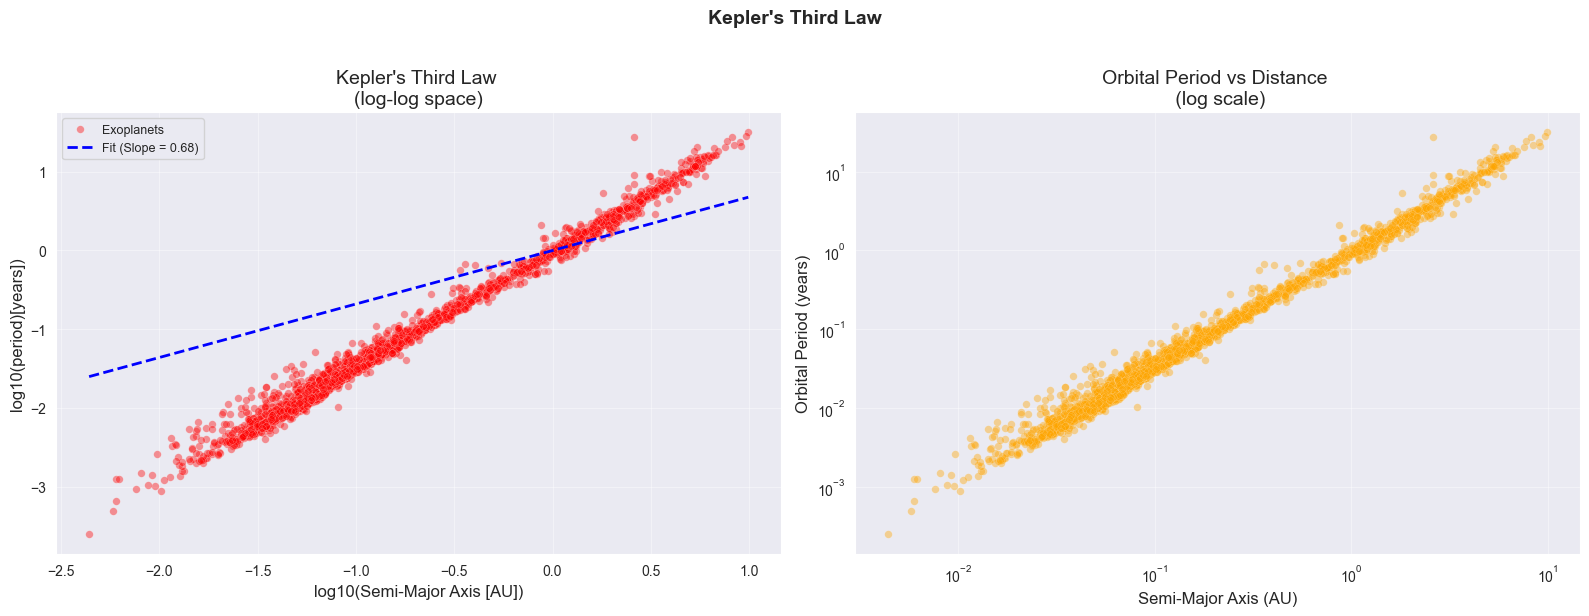

In [36]:
kepler = clean_d[["Orbital Period Days", "Orbit Semi-Major Axis"]].dropna()
print (f"Working with {len(kepler)} planets after filtering")
kepler = kepler.copy()
kepler["period years"] = kepler["Orbital Period Days"]/ 365.25
kepler = kepler[kepler["period years"] > 0]
kepler = kepler[kepler["Orbit Semi-Major Axis"] > 0]
kepler = kepler[kepler["period years"] < 1000]
kepler = kepler[kepler["Orbit Semi-Major Axis"] < 10]
print (f"\n Period (years) stats: ")
print (kepler["period years"].describe())
print (f"\n Semi-Major Axis (AU) stats: ")
print (kepler["Orbit Semi-Major Axis"].describe())
fig, axes = plt.subplots(1, 2, figsize = (16,6))
log_period = np.log10(kepler["period years"])
log_axis = np.log10(kepler["Orbit Semi-Major Axis"])
mask = np.isfinite(log_period) & np.isfinite(log_axis)
log_period_clean = log_period[mask]
log_axis_clean = log_axis[mask]
print (f"Points for regression: {mask.sum()}")
slope_k, intercept_k, r_K, p_K, se_K = stats.linregress(log_period_clean, log_axis_clean)
print (f"Slope: {slope_k:.3f}")
print (f"R-value: {r_K:.3f}")
print (f"P-value: {p_K:.6f}")
axes [0].scatter(
    log_axis_clean,
    log_period_clean,
    alpha = 0.4,
    color = "red",
    edgecolors = "white",
    linewidths = 0.3,
    s = 30,
    label = "Exoplanets"
)
x_line = np.linspace(log_axis_clean.min(),
                     log_axis_clean.max(), 100)
axes[0].plot(
    x_line,
    slope_k * x_line + intercept_k,
    color = "blue",
    linewidth = 2,
    linestyle = "--",
    label = f"Fit (Slope = {slope_k:.2f})"
)
axes[0].set_xlabel("log10(Semi-Major Axis [AU])", fontsize = 12)
axes[0].set_ylabel("log10(period)[years])", fontsize = 12)
axes[0].set_title("Kepler\'s Third Law \n(log-log space)",fontsize = 14)
axes[0].legend(fontsize = 9)
axes[0].grid(True, alpha = 0.4)

axes[1].scatter(
    kepler["Orbit Semi-Major Axis"][mask],
    kepler["period years"][mask],
    alpha = 0.4,
    color = "orange",
    edgecolors = "white",
    linewidths =0.2,
    s = 30
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Semi-Major Axis (AU)", fontsize = 12)
axes[1].set_ylabel("Orbital Period (years)", fontsize = 12)
axes[1].set_title("Orbital Period vs Distance \n (log scale)", fontsize = 14)
axes[1].grid(True, alpha = 0.4)
plt.suptitle("Kepler\'s Third Law", fontsize = 14, fontweight = "bold", y = 1.02 )
plt.tight_layout()
plt.show()

In theory, multi-planet systems, tend to have lower mean eccentricity as planets have companions who help stabilize each other's orbit paths leading to "more circular" orbits. Can the dataset prove this? The result of plotting eccentricity against number of planets per system shows consistency with the theory. A general trend of decreasing orbital eccentricity with increasing planet count. 6 planet systems show a mean eccentricity of 0.077, compared to 0.161 of single-planet systems, consistent with gravitational stabilization theory. The anomalous peak at 2-planet systems show destabilizing resonances in two-body configurations.  5 planet system also seems to have a higher eccentricity mean than 4 systems planets. This cold represent insufficient sample size (n = 49) rather than true astrophysical behavior.

Working with 1707 planets after filtering 
 
 Eccentricity stats: 
count    1707.000000
mean        0.154910
std         0.183289
min         0.000000
25%         0.014000
50%         0.092000
75%         0.220000
max         0.950000
Name: Eccentricity, dtype: float64

 Number of Planets stats: 
count    1707.000000
mean        1.778559
std         1.186653
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         6.000000
Name: Num Planets, dtype: float64
   Num Planets      mean  median       std  count
0            1  0.161402   0.088  0.199691    996
1            2  0.175932   0.130  0.173927    381
2            3  0.121425   0.079  0.131680    157
3            4  0.102796   0.070  0.110570     91
4            5  0.115851   0.060  0.163287     49
5            6  0.077273   0.059  0.067953     33


C:\Users\HP\AppData\Local\Temp\ipykernel_7804\649570646.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


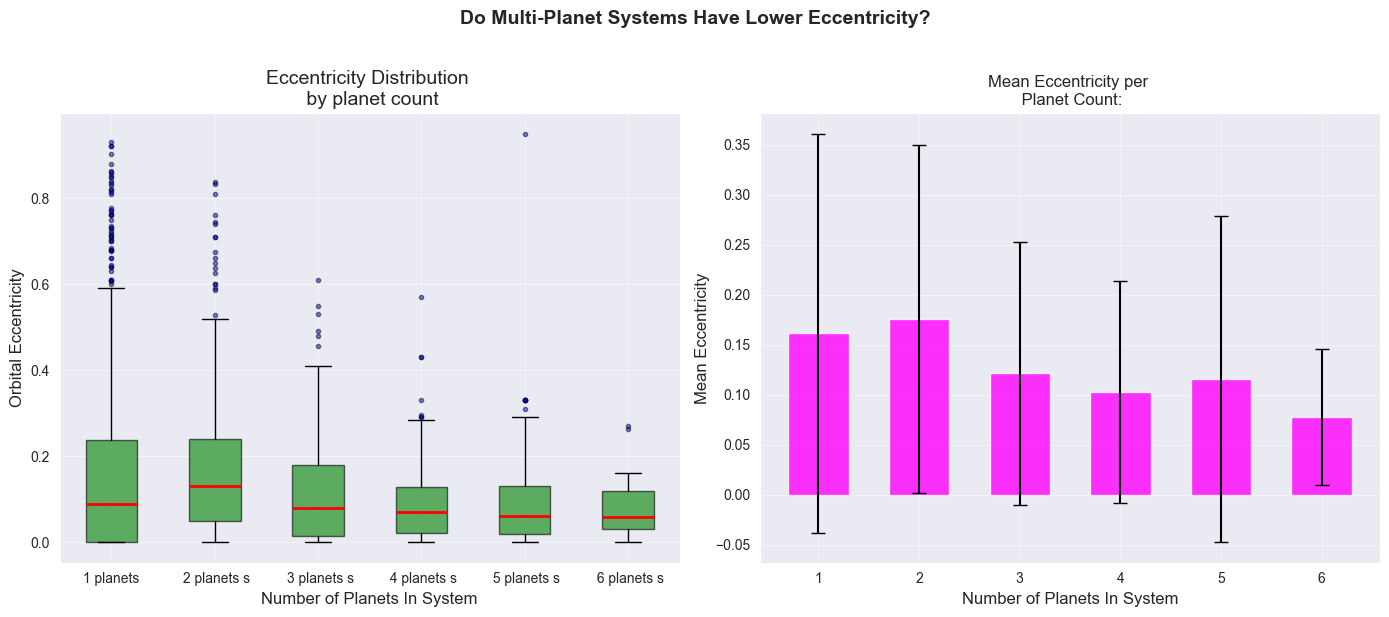

 
 Mean Eccentricity by Planet Count: 
   Num Planets      mean  count
0            1  0.161402    996
1            2  0.175932    381
2            3  0.121425    157
3            4  0.102796     91
4            5  0.115851     49
5            6  0.077273     33


In [37]:
ecc = clean_d[["Eccentricity", "Num Planets"]].dropna()
print (f"Working with {len(ecc)} planets after filtering ")
print (f" \n Eccentricity stats: ")
print (ecc["Eccentricity"].describe())
print (f"\n Number of Planets stats: ")
print (ecc["Num Planets"].describe())
fig, axes = plt.subplots(1, 2, figsize = (14,6))
ecc_grouped = ecc.groupby("Num Planets")["Eccentricity"].agg(['mean', 'median', 'std', 'count']).reset_index()
print (ecc_grouped)
planet_groups = []
labels = []
for n in sorted(ecc["Num Planets"].unique()):
    group_data = ecc[ecc["Num Planets"] == n]["Eccentricity"]
    planet_groups.append(group_data)
    labels.append(f" {int(n)} planets {"s" if n > 1 else ""}")
bp = axes[0].boxplot(
    planet_groups,
    labels = labels,
    patch_artist = True,
    boxprops = dict(facecolor = "green", alpha = 0.6),
    medianprops = dict(color = "red", linewidth = 2),
    whiskerprops = dict(color = "black"),
    capprops = dict(color = "black"),
    flierprops = dict(marker = "o", markerfacecolor = "blue", markersize = 3, alpha = 0.5)
)
axes[0].set_xlabel("Number of Planets In System", fontsize = 12)
axes[0].set_ylabel("Orbital Eccentricity", fontsize = 12)
axes[0].set_title("Eccentricity Distribution \n by planet count",fontsize = 14)
axes[0].grid(True, alpha = 0.4)
axes[1].bar(
    ecc_grouped["Num Planets"],
    ecc_grouped["mean"],
    color = "magenta",
    edgecolor = "white",
    alpha = 0.8,
    width = 0.6
)
axes[1].errorbar(
    ecc_grouped["Num Planets"],
    ecc_grouped["mean"],
    yerr = ecc_grouped["std"],
    fmt = 'none',
    color = "black",
    capsize = 5,
    linewidth = 1.5
)
axes[1].set_xlabel("Number of Planets In System", fontsize = 12)
axes[1].set_ylabel("Mean Eccentricity", fontsize = 12)
axes[1].set_title("Mean Eccentricity per \n Planet Count:")
axes[1].grid(True, alpha = 0.4)
plt.suptitle("Do Multi-Planet Systems Have Lower Eccentricity?", fontsize = 14, fontweight = "bold", y = 1.02 )
plt.tight_layout()
plt.show()
print (" \n Mean Eccentricity by Planet Count: ")
print (ecc_grouped[["Num Planets", "mean", "count"]].to_string())

Can the habitability of a planet be estimated? Through various factors, a habitability score can be made. Factors used here include: Stellar Temperature (should not be too hot nor too cold), Orbital distance (should lie at just the right distance to have liquid water), Eccentricity (should have low eccentric orbits for stable temperatures) and Stellar Mass (should not be too large - burns fuel faster which means short life span, nor should it be too small). HD 28185 b and Kepler - 22 b, show the most signs of supporting life.

In [38]:
hab_df = clean_d[[
    "Planet Name",
    "Stellar Effective Temperature",
    "Orbit Semi-Major Axis",
    "Eccentricity",
    "Stellar Mass"
]].dropna()
print (f"planets with all four factors {len(hab_df)}")
print (hab_df.describe())
hab_df = hab_df.copy()
def temp_score(t):
    if 4000 <= t <= 7000:
        return 1 - abs(t - 5778)/5778
    elif 3000 <= t < 4000:
        return 0.3
    else:
        return 0.0
hab_df["Temp Score"] = hab_df["Stellar Effective Temperature"].apply(temp_score)

def distance_score(a):
    if 0.5 <= a <= 2.0:
        return 1 - abs(a-1.0)/1.5
    elif 2.0 < a <= 3.0:
        return 0.1
    else:
        return 0.0
hab_df["Distance Score"] = hab_df["Orbit Semi-Major Axis"].apply(distance_score)

def eccentricity_score(e):
    if e <= 0.1:
        return 1.0
    elif e <= 0.3:
        return 1 - (e/0.3) * 0.5
    elif e <= 0.5:
        return 0.2
    else:
        return 0.0
hab_df["Eccentricity Score"] = hab_df["Eccentricity"].apply(eccentricity_score)

def mass_score(m):
    if 0.5 <= m <= 1.5:
        return 1 - abs(m - 1.0 ) / 1.0
    elif 0.3 < m <= 0.5:
        return 0.3
    else:
        return 0.0
hab_df["Mass Score"] = hab_df["Stellar Mass"].apply(mass_score)

hab_df["Habitability Index"] = (
    hab_df["Temp Score"] +
    hab_df["Distance Score"] +
    hab_df["Eccentricity Score"] +
    hab_df["Mass Score"]
    / 4
)
print (hab_df["Habitability Index"].describe())
print (f" \n Top most habitable planets: ")
print (
    hab_df[[
        "Planet Name",
        "Habitability Index",
        "Temp Score",
        "Distance Score",
        "Eccentricity Score",
        "Mass Score"
    ]].sort_values("Habitability Index", ascending = False).head(10).to_string()
)

planets with all four factors 1391
       Stellar Effective Temperature  Orbit Semi-Major Axis  Eccentricity  \
count                    1391.000000            1391.000000   1391.000000   
mean                     5311.090129               0.950288      0.165314   
std                      1428.603648               1.879645      0.187769   
min                      2904.000000               0.004400      0.000000   
25%                      4850.000000               0.051450      0.029000   
50%                      5453.000000               0.142900      0.100000   
75%                      5869.500000               1.224500      0.232000   
max                     40000.000000              23.000000      0.950000   

       Stellar Mass  
count   1391.000000  
mean       1.067067  
std        0.657740  
min        0.090000  
25%        0.810000  
50%        1.010000  
75%        1.220000  
max       10.940000  
count    1391.000000
mean        1.913820
std         0.491246
min       

Visualization of Habitability Index. From the visuals, distance is the least consistent factor, while eccentricity and temperature are the most consistent

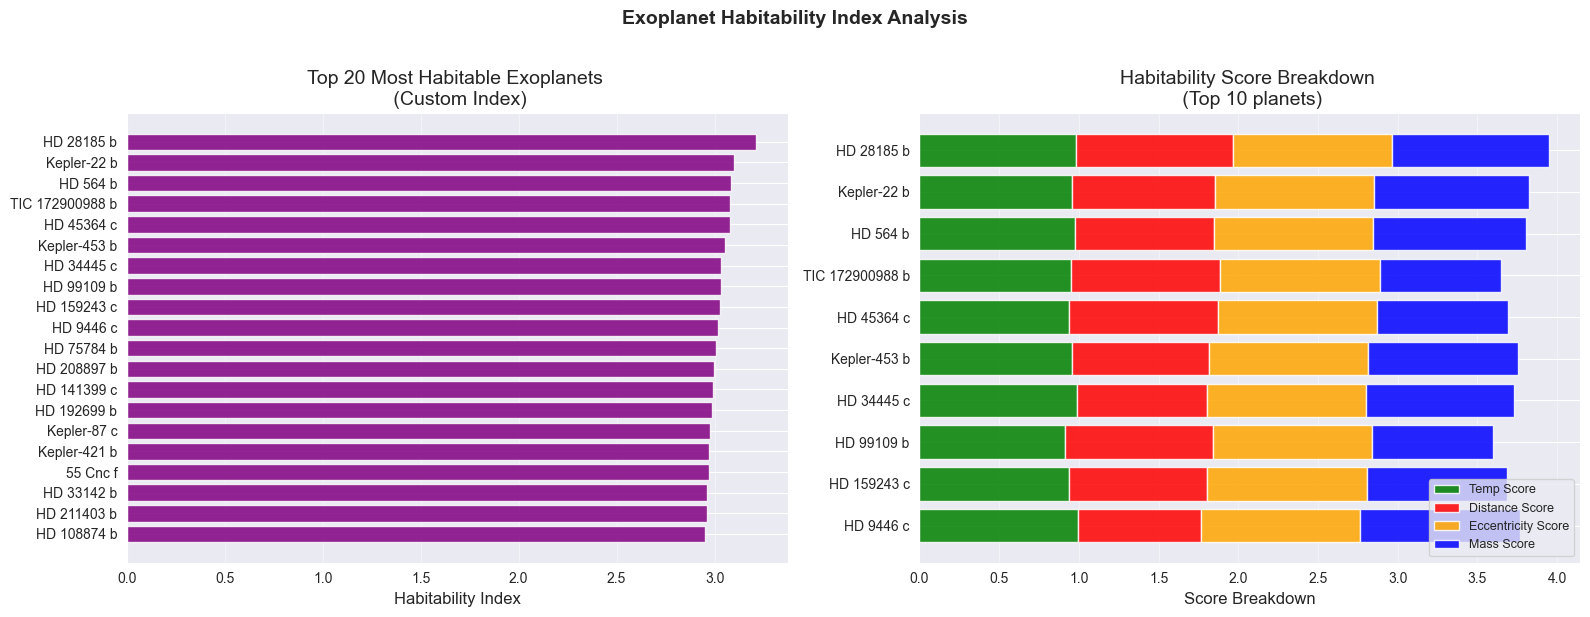

In [39]:
fig, (ax1, ax2 )= plt.subplots(1, 2,figsize = (16, 6))
top20 = hab_df.nlargest(20, "Habitability Index")
ax1.barh(
    top20["Planet Name"],
    top20["Habitability Index"],
    color = "purple",
    edgecolor = "white",
    alpha = 0.85
)
ax1.set_xlabel("Habitability Index", fontsize = 12)
ax1.set_title("Top 20 Most Habitable Exoplanets \n (Custom Index)", fontsize = 14)
ax1.grid(True, alpha = 0.4, axis = "x")
ax1.invert_yaxis()#highest at the top


top10 = hab_df.nlargest(10, "Habitability Index")
score_cols = [
    "Temp Score",
    "Distance Score",
    "Eccentricity Score",
    "Mass Score"
]

colors = ["green", "red", "orange", "blue"]
bottom = np.zeros(len(top10))
for i, col in enumerate(score_cols):
    ax2.barh(
        top10["Planet Name"],
        top10[col],
        left = bottom,
        label = col.replace('score',""),
        color = colors[i],
        edgecolor = "white",
        alpha = 0.85
    )
    bottom += top10[col].values

ax2.set_xlabel("Score Breakdown", fontsize = 12)
ax2.set_title("Habitability Score Breakdown \n (Top 10 planets)", fontsize = 14)
ax2.legend(loc = "lower right", fontsize = 9)
ax2.grid(True, alpha = 0.4, axis = "x")
ax2.invert_yaxis()
plt.suptitle("Exoplanet Habitability Index Analysis", fontsize = 14, fontweight = "bold", y = 1.02 )
plt.tight_layout()
plt.show()


